# 종합 실습 1 - 이진분류

이번 실습에서는 `Breast Cancer Wisconsin` 데이터를 사용한다.

- 목표: 악성(`malignant`) / 양성(`benign`) 종양을 구분하는 이진분류
- 입력 feature 수: 30개
- 출력: 0 또는 1
- 사용 개념
    - train / validation / test 분리
    - Standardization
    - DataLoader
    - MLP
    - He 초기화
    - Batch Normalization
    - Dropout
    - BCEWithLogitsLoss
    - AdamW
    - ReduceLROnPlateau
    - Early Stopping
    - best model 선택 및 평가

In [1]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 1. 데이터 이해

이 데이터는 유방암 진단과 관련된 수치형 feature로 이루어져 있다.  
딥러닝 관점에서는 **30개의 입력값을 받아 0/1을 예측하는 표 형태(tabular) 이진분류 문제** 라고 보면 된다.

- `target=0`: malignant(악성)
- `target=1`: benign(양성)


In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print('X shape:', X.shape)
print('y shape:', y.shape)
print('class names:', data.target_names)
print('feature sample:', data.feature_names[:5])
print('target counts:', np.bincount(y))

X shape: (569, 30)
y shape: (569,)
class names: ['malignant' 'benign']
feature sample: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']
target counts: [212 357]


## 2. train / validation / test 분리

- train: 모델 학습
- validation: 학습 중 성능 확인, 하이퍼파라미터 비교, early stopping 기준
- test: 마지막 최종 평가

분류 문제이므로 클래스 비율이 한쪽으로 치우치지 않도록 `stratify=y`를 사용한다.

In [3]:
# TODO 1. 전체 데이터를 train / validation / test 구조로 분할
# - 첫 번째 분할: test_size=0.3, random_state=SEED, stratify=y
# - 두 번째 분할: validation / test로 반반 나누기

# raise NotImplementedError('전체 데이터를 train / validation / test 구조로 분할해보세요.')
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print('train:', X_train.shape, y_train.shape)
print('val  :', X_val.shape, y_val.shape)
print('test :', X_test.shape, y_test.shape)

train: (398, 30) (398,)
val  : (85, 30) (85,)
test : (86, 30) (86,)


## 3. 입력 정규화

표 형태 데이터에서는 feature마다 값의 범위가 크게 다를 수 있다.  
이 차이를 줄여주면 학습이 더 안정적으로 진행되는 경우가 많다.

주의할 점은 이미 배운 것처럼,
`scaler.fit()`은 **train 데이터에만** 해야 한다는 점이다.  
validation / test에는 train에서 학습한 기준을 그대로 적용한다.


In [4]:
# TODO 2. StandardScaler를 이용해 입력을 정규화
# - fit은 train 데이터에만 한다.
# - validation, test에는 transform만 사용한다.

# raise NotImplementedError('정규화 코드를 완성해보세요.')
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print('train mean (first 3 features):', X_train_scaled[:, :3].mean(axis=0))
print('train std  (first 3 features):', X_train_scaled[:, :3].std(axis=0))

train mean (first 3 features): [-4.97480337e-15  2.74863884e-15  2.03912822e-15]
train std  (first 3 features): [1. 1. 1.]


## 4. Tensor 변환과 DataLoader 준비

PyTorch 모델이 학습하려면 numpy 배열을 tensor로 바꿔야 한다.  
또한 미니배치 학습을 위해 `TensorDataset`, `DataLoader`를 사용한다.


In [5]:
# TODO 3. Tensor와 DataLoader를 준비
# - X는 float32
# - y는 float32로 바꾸고 view(-1, 1) 형태로 맞춘다.
# - train_loader는 shuffle=True

# raise NotImplementedError('Tensor 변환과 DataLoader 준비 코드를 완성해보세요.')
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

xb, yb = next(iter(train_loader))
print('mini batch X shape:', xb.shape)
print('mini batch y shape:', yb.shape)

mini batch X shape: torch.Size([32, 30])
mini batch y shape: torch.Size([32, 1])


## 5. 이진분류용 MLP 모델 만들기

이번 모델에는 다음 요소를 넣어본다.

- `Linear`
- `BatchNorm1d`
- `ReLU`
- `Dropout`
- 마지막 출력층 1개

마지막에 sigmoid를 직접 넣지 않는 이유는  
손실 함수로 `BCEWithLogitsLoss`를 사용할 것이기 때문이다.  
이 손실 함수는 내부적으로 sigmoid를 포함한 형태라서 수치적으로 더 안정적이다.


In [6]:
class BreastCancerMLP(nn.Module):
    def __init__(self, input_dim=30, hidden_dims=[64, 32], dropout_rate=0.3):
        super().__init__()

        # TODO 4. 이진분류용 MLP를 완성
        # - Linear -> BatchNorm1d -> ReLU -> Dropout 흐름을 사용한다.
        # - 마지막 출력층 뉴런 수는 1개이다.

        # raise NotImplementedError('모델 구조를 완성해보세요.')

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')
                nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.net(x)

model = BreastCancerMLP()
print(model)

BreastCancerMLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 6. 학습/평가 함수 만들기

코드를 구조화해서 관리하는 습관도 중요하다.

- `train_one_epoch()`: 한 epoch 학습
- `evaluate()`: validation / test 평가
- accuracy 뿐 아니라 precision, recall, f1도 함께 본다.

이진분류이므로
1. 모델 출력(logit)에 sigmoid를 적용해 확률로 바꾸고
2. 0.5 기준으로 0/1을 결정한다.

In [7]:
def get_binary_predictions_from_logits(logits, threshold=0.5):
    # TODO 5-1. logits를 확률로 바꾸고, threshold 기준으로 0/1 예측값을 만든다.

    # raise NotImplementedError('sigmoid와 threshold 코드를 완성해보세요.')
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    return probs, preds


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_targets = []

    for X_batch, y_batch in loader:
        # TODO 5-2. 학습 step의 핵심 5줄을 완성
        # 1. gradient 초기화
        # 2. 순전파
        # 3. loss 계산
        # 4. 역전파
        # 5. optimizer step

        # raise NotImplementedError('학습 루프 핵심 코드를 완성해보세요.')
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        _, preds = get_binary_predictions_from_logits(logits)
        all_preds.append(preds.detach())
        all_targets.append(y_batch.detach())

    epoch_loss = running_loss / len(loader.dataset)
    y_true = torch.cat(all_targets).numpy().ravel()
    y_pred = torch.cat(all_preds).numpy().ravel()

    epoch_acc = accuracy_score(y_true, y_pred)
    return epoch_loss, epoch_acc


def evaluate_binary_model(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    all_probs = []
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            probs, preds = get_binary_predictions_from_logits(logits)
            all_probs.append(probs)
            all_preds.append(preds)
            all_targets.append(y_batch)

    epoch_loss = running_loss / len(loader.dataset)

    y_true = torch.cat(all_targets).numpy().ravel()
    y_prob = torch.cat(all_probs).numpy().ravel()
    y_pred = torch.cat(all_preds).numpy().ravel()

    metrics = {
        'loss': epoch_loss,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
    }
    return metrics, y_true, y_prob, y_pred

## 7. optimizer, scheduler, early stopping 준비

- optimizer: `AdamW`
- scheduler: `ReduceLROnPlateau`
- early stopping: validation loss 기준

을 사용한다.

이 조합은 표 형태 데이터 실습에서도 자주 쓰는 무난한 출발점이다.

In [8]:
# TODO 6. 손실 함수, optimizer, scheduler를 설정
# - 손실 함수: BCEWithLogitsLoss
# - optimizer: AdamW, lr=0.001, weight_decay=1e-4
# - scheduler: ReduceLROnPlateau, mode='min', factor=0.5, patience=5

# raise NotImplementedError('criterion / optimizer / scheduler 설정을 완성해보세요.')
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


## 8. 전체 학습 루프

학습 중에 기록할 것들

- train loss / accuracy
- validation loss / accuracy
- learning rate
- best validation loss
- patience 카운트

validation loss가 가장 좋았던 시점의 가중치를 저장해두고, 일정 epoch 동안 개선이 없으면 학습을 멈춘다.

In [9]:
num_epochs = 100
early_stopping_patience = 12

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []
}

best_val_loss = float('inf')
best_epoch = 0
best_state = copy.deepcopy(model.state_dict())
patience_counter = 0

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_metrics, _, _, _ = evaluate_binary_model(model, val_loader, criterion)

    # TODO 7-1. scheduler에 validation loss를 전달
    # raise NotImplementedError('scheduler.step(...) 부분을 완성해보세요.')
    scheduler.step(val_metrics['loss'])

    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['lr'].append(current_lr)

    # TODO 7-2. best model 갱신과 patience 카운트를 완성
    # raise NotImplementedError('best_state / patience 갱신 로직을 완성해보세요.')
    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(
            f'Epoch {epoch:03d} | '
            f'train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | '
            f'val_loss={val_metrics["loss"]:.4f} | val_acc={val_metrics["accuracy"]:.4f} | '
            f'lr={current_lr:.6f}'
        )

    if patience_counter >= early_stopping_patience:
        print(f'early stopping at epoch {epoch}')
        break

print('best epoch:', best_epoch)
print('best val loss:', round(best_val_loss, 4))


Epoch 001 | train_loss=0.8569 | train_acc=0.4397 | val_loss=0.5831 | val_acc=0.6353 | lr=0.001000
Epoch 010 | train_loss=0.2233 | train_acc=0.9397 | val_loss=0.1833 | val_acc=0.9647 | lr=0.001000
Epoch 020 | train_loss=0.1436 | train_acc=0.9598 | val_loss=0.1122 | val_acc=0.9765 | lr=0.001000
Epoch 030 | train_loss=0.0990 | train_acc=0.9824 | val_loss=0.0797 | val_acc=0.9765 | lr=0.001000
Epoch 040 | train_loss=0.1076 | train_acc=0.9698 | val_loss=0.0637 | val_acc=0.9765 | lr=0.001000
Epoch 050 | train_loss=0.0837 | train_acc=0.9774 | val_loss=0.0518 | val_acc=0.9765 | lr=0.001000
Epoch 060 | train_loss=0.0584 | train_acc=0.9799 | val_loss=0.0471 | val_acc=0.9765 | lr=0.001000
Epoch 070 | train_loss=0.0677 | train_acc=0.9774 | val_loss=0.0489 | val_acc=0.9765 | lr=0.000500
Epoch 080 | train_loss=0.0789 | train_acc=0.9749 | val_loss=0.0445 | val_acc=0.9765 | lr=0.000500
early stopping at epoch 89
best epoch: 77
best val loss: 0.0391


## 9. 학습 곡선 확인

숫자 하나만 보기보다 곡선을 보고 학습 상태를 해석하는 습관도 중요하다.

- loss가 안정적으로 줄어드는지
- validation 성능이 어느 시점부터 정체되는지
- learning rate가 어떻게 줄었는지

를 확인한다.

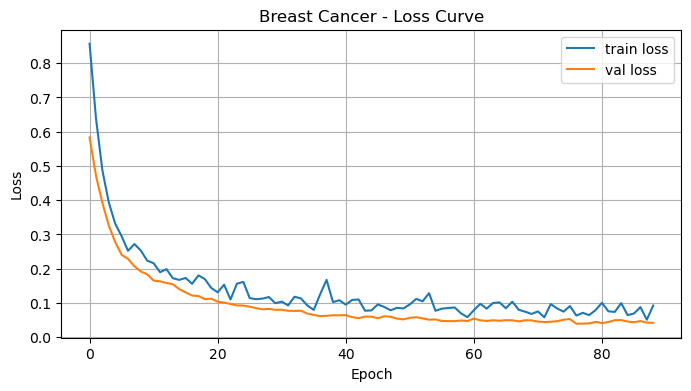

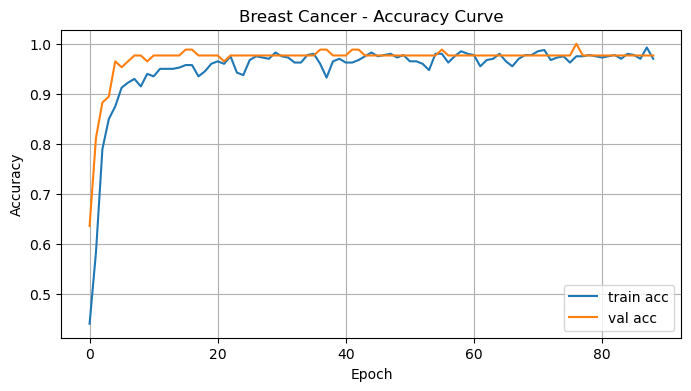

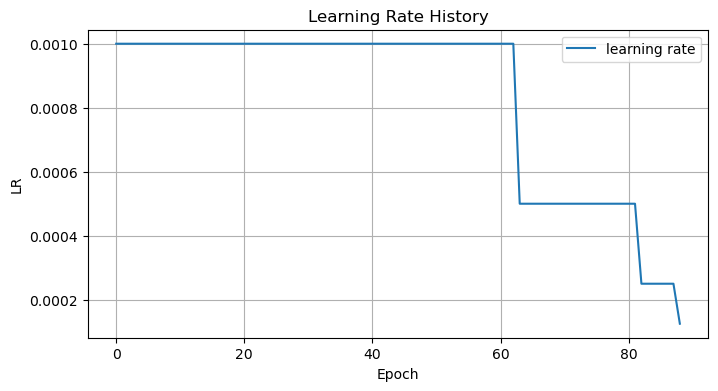

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='train loss')
plt.plot(history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Breast Cancer - Loss Curve')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history['train_acc'], label='train acc')
plt.plot(history['val_acc'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Breast Cancer - Accuracy Curve')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history['lr'], label='learning rate')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.title('Learning Rate History')
plt.legend()
plt.grid()
plt.show()


## 10. best model로 복원 후 test 평가

마지막 epoch 모델이 아니라  
validation loss가 가장 좋았던 시점의 모델로 되돌린 뒤 test를 평가한다.

이 흐름이 early stopping / checkpoint의 핵심이다.


In [11]:
# TODO 8. best_state를 다시 불러오고 test 성능을 평가

# raise NotImplementedError('best model 복원과 test 평가 코드를 완성해보세요.')
model.load_state_dict(best_state)

test_metrics, y_true_test, y_prob_test, y_pred_test = evaluate_binary_model(
    model, test_loader, criterion
)

print('test metrics')
for key, value in test_metrics.items():
    print(f'- {key}: {value:.4f}')

test metrics
- loss: 0.0916
- accuracy: 0.9651
- precision: 0.9474
- recall: 1.0000
- f1: 0.9730


## 11. Confusion Matrix 확인

정확도 하나만 보면 무엇을 잘 맞추고 무엇을 놓치는지 보이지 않을 수 있다.  
그래서 분류 문제에서는 confusion matrix도 함께 보는 습관이 좋다.


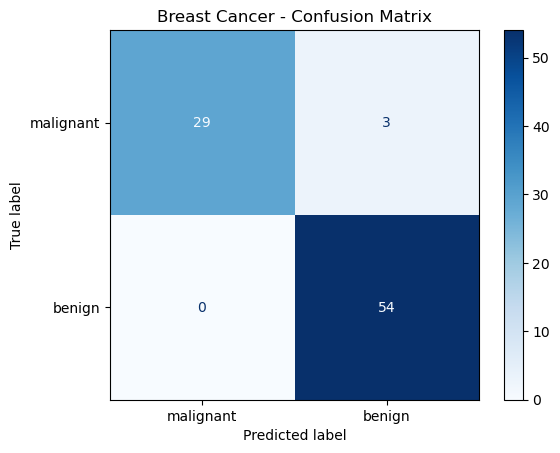

In [12]:
cm = confusion_matrix(y_true_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title('Breast Cancer - Confusion Matrix')
plt.show()

## 12. 몇 개 샘플 직접 보기

실제 예측 결과를 몇 개 직접 확인해보면  
모델 출력(logit) → 확률 → 최종 클래스 결정 흐름을 다시 점검할 수 있다.

In [13]:
sample_indices = np.arange(min(10, len(X_test_tensor)))

model.eval()
with torch.no_grad():
    sample_X = X_test_tensor[sample_indices]
    sample_logits = model(sample_X)
    sample_probs = torch.sigmoid(sample_logits).cpu().numpy().ravel()
    sample_preds = (sample_probs >= 0.5).astype(int)

for i, idx in enumerate(sample_indices):
    print(
        f'index={idx:2d} | '
        f'true={int(y_test[idx])} | '
        f'prob={sample_probs[i]:.4f} | '
        f'pred={sample_preds[i]}'
    )

index= 0 | true=1 | prob=0.9900 | pred=1
index= 1 | true=0 | prob=0.0009 | pred=0
index= 2 | true=0 | prob=0.0007 | pred=0
index= 3 | true=0 | prob=0.0001 | pred=0
index= 4 | true=0 | prob=0.3224 | pred=0
index= 5 | true=1 | prob=0.9605 | pred=1
index= 6 | true=0 | prob=0.9384 | pred=1
index= 7 | true=1 | prob=0.9972 | pred=1
index= 8 | true=1 | prob=0.7991 | pred=1
index= 9 | true=0 | prob=0.2605 | pred=0
